<a href="https://colab.research.google.com/github/iamArham10/building-rag/blob/main/embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
%pip install sentence-transformers langchain-groq langchain-huggingface langchain-community faiss-cpu
%pip install numpy matplotlib scikit-learn
%pip install langchain langchain-text-splitters pymupdf pydantic rich arxiv

In [4]:
import os
from getpass import getpass

# This will pop up an input box at the top of VS Code when you run the cell
os.environ["GROQ_API_KEY"] = getpass("Enter your GROQ_API_KEY: ")

print("Key loaded successfully!")

Enter your GROQ_API_KEY: ··········
Key loaded successfully!


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
from rich.console import Console
from rich.style import Style

console = Console()
pprint = partial(console.print, style=Style(color="#00AAFF", bold=True))

## What is an Embedding?

An **embedding** is a fixed-length list of floating-point numbers (a **vector**) that represents the *meaning* of a piece of text.

```
"Italy is famous for pasta"   →  [0.12, -0.45, 0.83, ..., 0.07]   ← 384 numbers
"Rome is known for its food"  →  [0.14, -0.41, 0.79, ..., 0.09]   ← 384 numbers
"The sky is blue"             →  [-0.63, 0.21, -0.12, ..., 0.55]  ← 384 numbers
```

The first two sentences have **similar vectors** becaue they're both about Italian food.  
The third sentence has a **very different vector** because completely different topic.

In [6]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-mpnet-base-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
pprint(model.get_embedding_dimension()) # embedding vector length
pprint(model.max_seq_length) # max input tokens

768

384

## Encoding Text

In [7]:
embeddings = model.encode(
    ["hi how you doing", "where are you going", "what are you doing"], # sentence can be str or list[str]
    batch_size=32, # how many sentences to process at once
    show_progress_bar=True, # progress bar
    normalize_embeddings=True # L2 normalize each vector -> length 1
)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
print(type(embeddings)) # numpy d array of shape (n_sentences, n_dimensions)
print(embeddings.shape)

<class 'numpy.ndarray'>
(3, 768)


### Large Scale Embedding & Similarity Example
In this example, we generate embeddings for a diverse set of sentences and calculate a **Similarity Matrix**. Because the embeddings are normalized, the dot product between any two vectors is equal to their **Cosine Similarity** (a value between -1 and 1, where 1 means identical).

In [10]:
sentences = [
    "The new smartphone has a powerful processor.",
    "Artificial Intelligence is changing the tech industry.",
    "The deep forest is home to many rare animals.",
    "Hiking in the mountains provides a fresh perspective.",
    "I love eating spicy Italian pasta for dinner.",
    "The chef prepared a delicious three-course meal."
]

# Encode all sentences at once
large_embeddings = model.encode(
    sentences,
    show_progress_bar=True,
    normalize_embeddings=True
)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [11]:
# Example data

queries = [
    "What's the weather like in the Rocky Mountains?",
    "What kinds of food is Italy known for?",
    "What's my name? I bet you don't remember...",
    "What's the point of life anyways?",
    "The point of life is to have fun :D",
]

documents = [
    "Kamchatka's weather is cold, with long severe winters and short cool summers.",
    "Italy is famous for pasta, pizza, gelato, and espresso.",
    "I can't recall personal names — I can only provide general information.",
    "Life's purpose varies; it's often seen as personal fulfillment and growth.",
    "Enjoying life's moments is indeed a wonderful approach to living.",
]

# Encode both
q_embeddings = model.encode(queries,    normalize_embeddings=True)
d_embeddings = model.encode(documents,  normalize_embeddings=True)

print(f"Query embeddings shape    : {q_embeddings.shape}")   # (5, 768)
print(f"Document embeddings shape : {d_embeddings.shape}")   # (5, 768)

Query embeddings shape    : (5, 768)
Document embeddings shape : (5, 768)


## Cosine Similarity

Cosine similarity measures the angle between the vectors.

1. 1.0 if vector points the same direction -> very similar meaning

2. 0.0 unrelated

3. -1.0 opposite meaning

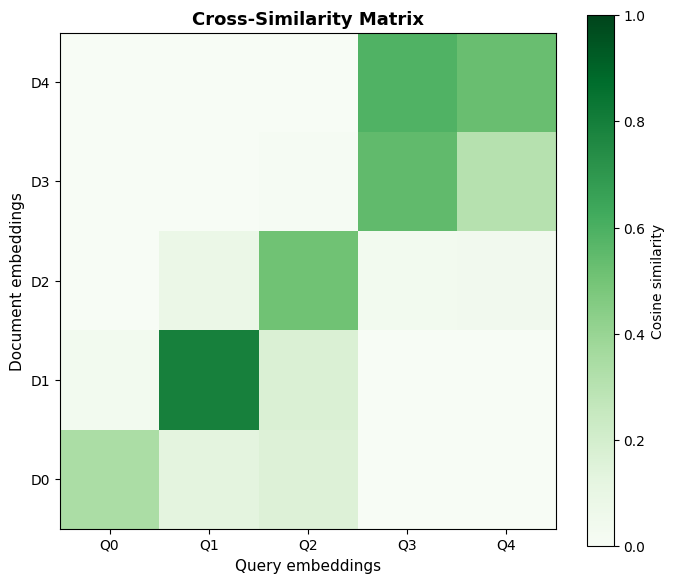

In [12]:
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np

def plot_similarity_matrix(emb1, emb2, xlabel="", ylabel="", title=""):
    sim_matrix = cosine_similarity(emb1, emb2)
    plt.imshow(sim_matrix, cmap="Greens", interpolation="nearest", vmin=0, vmax=1)
    plt.colorbar(label="Cosine similarity")
    plt.gca().invert_yaxis()
    plt.title(title, fontsize=13, fontweight="bold")
    plt.xlabel(xlabel, fontsize=11)
    plt.ylabel(ylabel, fontsize=11)
    plt.xticks(range(len(queries)), [f"Q{i}" for i in range(5)])
    plt.yticks(range(len(documents)), [f"D{i}" for i in range(5)])

plt.figure(figsize=(7, 6))
plot_similarity_matrix(q_embeddings, d_embeddings,
    xlabel="Query embeddings",
    ylabel="Document embeddings",
    title="Cross-Similarity Matrix")
plt.tight_layout()
plt.show()

In [13]:
import pandas as pd

sim = cosine_similarity(q_embeddings, d_embeddings)

df_results = pd.DataFrame(
    sim,
    index=[f"Query {i}: {q[:40]}..." for i, q in enumerate(queries)],
    columns=[f"Doc {i}" for i in range(len(documents))]
)

def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: #dcfce7; font-weight: bold' if v else '' for v in is_max]

pprint("Similarity Matrix (Rows = Queries, Cols = Documents)")
display(df_results.style.apply(highlight_max, axis=1).format("{:.3f}"))

Similarity Matrix (Rows = Queries, Cols = Documents)

,Doc 0,Doc 1,Doc 2,Doc 3,Doc 4
Query 0: What's the weather like in the Rocky Mou...,0.341,0.127,0.156,-0.086,-0.022
Query 1: What kinds of food is Italy known for?...,0.032,0.789,0.169,-0.011,-0.027
Query 2: What's my name? I bet you don't remember...,-0.037,0.084,0.510,0.032,0.042
Query 3: What's the point of life anyways?...,-0.072,-0.080,0.010,0.546,0.308
Query 4: The point of life is to have fun :D...,-0.043,-0.061,-0.048,0.589,0.524


## Symmetric vs Bi-encoder

The problem is the query and the matching document are different

- Query: `"What food is Italy known for?"` — short, question-like

- Document: `"Italy is famous for pasta, pizza, gelato, and espresso."` — longer, declarative

A **symmetric encoder** treats both the same way.  

A **bi-encoder** uses slightly different encoding for each role, trained to make them land close together even though they look different.

In [14]:
# using bi encoder
from sentence_transformers import SentenceTransformer

# Symmetric model
sym_model = SentenceTransformer("all-MiniLM-L6-v2")

# Asymmetric / bi-encoder model
bi_model  = SentenceTransformer("multi-qa-MiniLM-L6-cos-v1")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


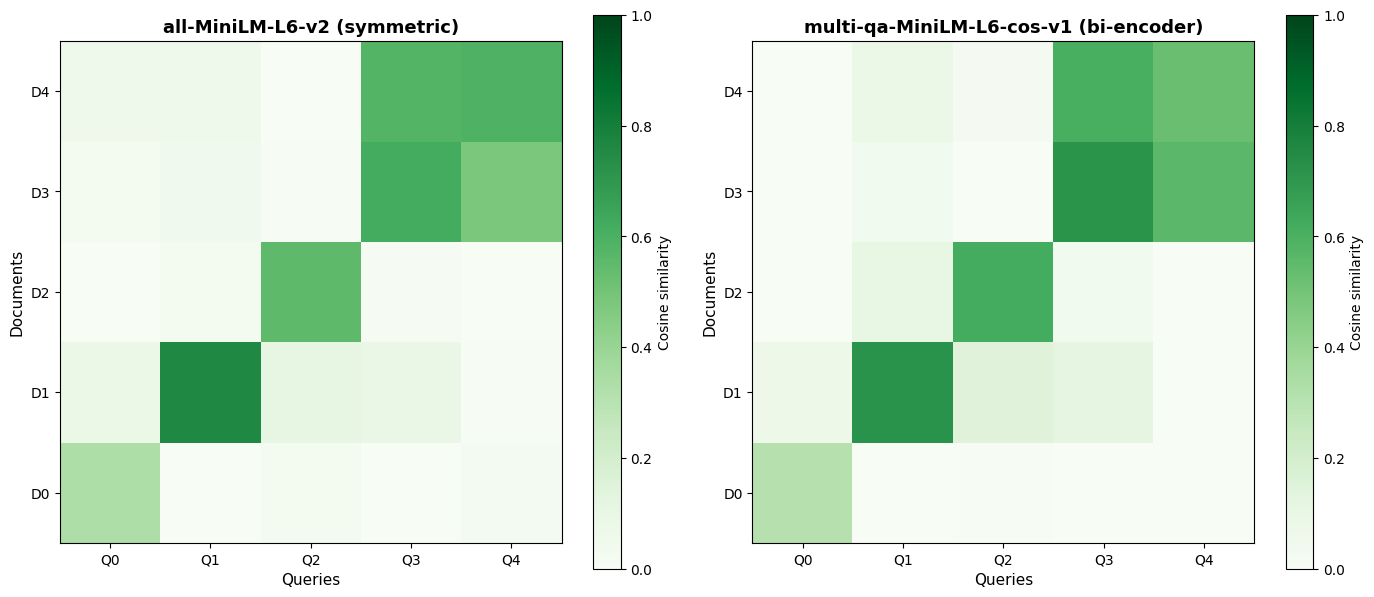

In [15]:
query_symmetric = sym_model.encode(queries, normalize_embeddings=True)
doc_symmetric   = sym_model.encode(documents, normalize_embeddings=True)

query_bi = bi_model.encode(queries, normalize_embeddings=True)
doc_bi   = bi_model.encode(documents, normalize_embeddings=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plt.sca(axes[0])
plot_similarity_matrix(query_symmetric, doc_symmetric,
    xlabel="Queries", ylabel="Documents",
    title="all-MiniLM-L6-v2 (symmetric)")

plt.sca(axes[1])
plot_similarity_matrix(query_bi, doc_bi,
    xlabel="Queries", ylabel="Documents",
    title="multi-qa-MiniLM-L6-cos-v1 (bi-encoder)")

plt.tight_layout()
plt.show()

## Langchain Integration with HuggingFaceEmbeddings

In [16]:
from langchain_huggingface import HuggingFaceEmbeddings

embedder = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True}
    )

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Two methods to understand

1. `.embed_query(text)` — for a single search query


```single_embedding = embedder.embed_query("What food is Italy known for?")```

2. `.embed_documents(texts)` — for a batch of documents


```doc_embeddings = embedder.embed_documents(["Italy is famous for pasta and pizza.", "Kamchatka's weather is very cold.", "Life's purpose varies by person"])```

In [17]:
print(embedder.embed_query("What food is italy know for"))

[-0.0211226437240839, 0.035372793674468994, 0.010032327845692635, 0.0890536829829216, -0.03501120209693909, 0.008475752547383308, 0.048791415989398956, -0.06368128955364227, -0.03466655686497688, -0.07597523182630539, 0.056925587356090546, -0.0671171322464943, -0.08487160503864288, 0.04648572951555252, -0.05387863889336586, -0.06012880802154541, 0.0895330086350441, 0.0681023970246315, 0.004084080457687378, -0.04959461838006973, 0.012959389016032219, -0.012670393101871014, 0.06493868678808212, 0.015745099633932114, 0.025451697409152985, 0.03610328957438469, 0.04581713303923607, 0.0021083548199385405, -0.058325450867414474, -0.024280376732349396, 0.00991929043084383, 0.04689865931868553, 0.0694902315735817, -0.05318784713745117, 0.01685565523803234, 0.04681630805134773, 0.11593343317508698, -0.1253049075603485, 0.0586983896791935, 0.0005780700012110174, 0.021274128928780556, -0.025622939690947533, 0.09664158523082733, 0.046777959913015366, 0.047839511185884476, 0.04214220866560936, -0.00

In [18]:
print(embedder.embed_documents(["Italy is famous for pasta and pizza", "Spain's weather is pleasant"]))

[[-0.04896017163991928, 0.05150556191802025, -0.030865341424942017, 0.07001717388629913, -0.05895853042602539, 0.03476935252547264, 0.02023725025355816, 0.010782377794384956, 0.0022886269725859165, -0.12055794894695282, 0.025406289845705032, -0.06287200003862381, -0.0024020622950047255, 0.0429099015891552, -0.010261780582368374, -0.06189608573913574, 0.11466427147388458, 0.03877858817577362, 0.017417242750525475, -0.027826078236103058, -0.03734597563743591, -0.06447230279445648, 0.03673901408910751, 0.02219000831246376, 0.0924602672457695, 0.038440387696027756, 0.03293178975582123, -0.010979306884109974, -0.03959425166249275, 0.012258553877472878, -0.04375436529517174, 0.07249640673398972, 0.026940401643514633, -0.04529838636517525, 0.058072544634342194, 0.06473693996667862, 0.03479134291410446, -0.0905977264046669, 0.0626738965511322, -0.03410260006785393, 0.04491441324353218, 0.030742427334189415, 0.11610781401395798, -0.008752593770623207, 0.07129056751728058, 0.01743142679333687, 0

## Semantic Guardrails

Semantic guardrails is a filter that runs before your expensive **LLM** call. It uses embeddings to check whether the user query is on-topic.

In [19]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

ALLOWED_TOPIC_EXAMPLES = [
    "How do I make pasta?",
    "What temperature should I bake a cake at?",
    "What spices go well with chicken?",
    "How do I chop an onion safely?",
    "What is the difference between baking soda and baking powder?",
    "Can you suggest a vegetarian recipe?",
    "How long should I marinate meat?",
]

allowed_embeds = model.encode(ALLOWED_TOPIC_EXAMPLES, normalize_embeddings=True)

def semantic_guardrail(query: str, threshold: float=0.35):
    query_emb  = model.encode([query], normalize_embeddings=True)
    scores     = cosine_similarity(query_emb, allowed_embeds)[0]
    max_idx    = int(scores.argmax())
    max_score  = float(scores[max_idx])
    best_match = ALLOWED_TOPIC_EXAMPLES[max_idx]
    passed     = max_score >= threshold

    reason = (
        f"PASSED score={max_score:.3f} ≥ {threshold} | closest: '{best_match}'"
        if passed else
        f"REJECTED score={max_score:.3f} < {threshold} | closest: '{best_match}'"
    )

    return {"passed": passed, "max_score": max_score,
            "best_match": best_match, "reason": reason}

In [20]:
test_queries = [
    "What's the best way to roast vegetables?",
    "Can you help me write a Python script?",
    "How do I season a cast iron pan?",
    "What is the capital of France?",
    "Give me a chocolate chip cookie recipe.",
    "How do I hack into a computer?",
]

for q in test_queries:
    result = semantic_guardrail(q, threshold=0.25)
    print(f"Q: {q[:50]:<50}  {result['reason']}")

Q: What's the best way to roast vegetables?            PASSED score=0.410 ≥ 0.25 | closest: 'How do I chop an onion safely?'
Q: Can you help me write a Python script?              REJECTED score=0.134 < 0.25 | closest: 'How do I make pasta?'
Q: How do I season a cast iron pan?                    PASSED score=0.273 ≥ 0.25 | closest: 'How long should I marinate meat?'
Q: What is the capital of France?                      REJECTED score=0.165 < 0.25 | closest: 'What spices go well with chicken?'
Q: Give me a chocolate chip cookie recipe.             PASSED score=0.358 ≥ 0.25 | closest: 'How do I make pasta?'
Q: How do I hack into a computer?                      REJECTED score=0.212 < 0.25 | closest: 'How do I make pasta?'


### Limitations of Semantic guardrails

Semantic guardrails are fast and useful but not perfect. Be aware:

- **They can be fooled** by adversarial queries that are semantically close to allowed topics
    but with harmful intent ("how do I chop someone?")
- **Threshold tuning is domain-specific** — what works for cooking won't work for legal advice
- **They are a first filter**, not a complete safety system. Always combine with LLM-level
    safety prompts for production systems

## Expanding Documents and Re-Test

[Q0] What's the weather like in the Rocky Mountains?
→ The Rocky Mountains are a region of breathtaking vistas and unforgiving climate, with weather patterns that can shift dr...

[Q1] What kinds of food is Italy known for?
→ Italy's rich culinary landscape is a testament to its reputation as a gastronomic paradise. The country is renowned for ...

[Q2] What's my name? I bet you don't remember...
→ As I reflect on our previous encounters, I'm afraid I don't have a crystal-clear recollection of your name. My memory, t...

[Q3] What's the point of life anyways?
→ The existential query of what gives life its purpose has puzzled philosophers, theologians, and everyday individuals for...

[Q4] The point of life is to have fun :D
→ The notion that the primary purpose of existence is to indulge in merriment and amusement may seem simplistic, yet it ho...



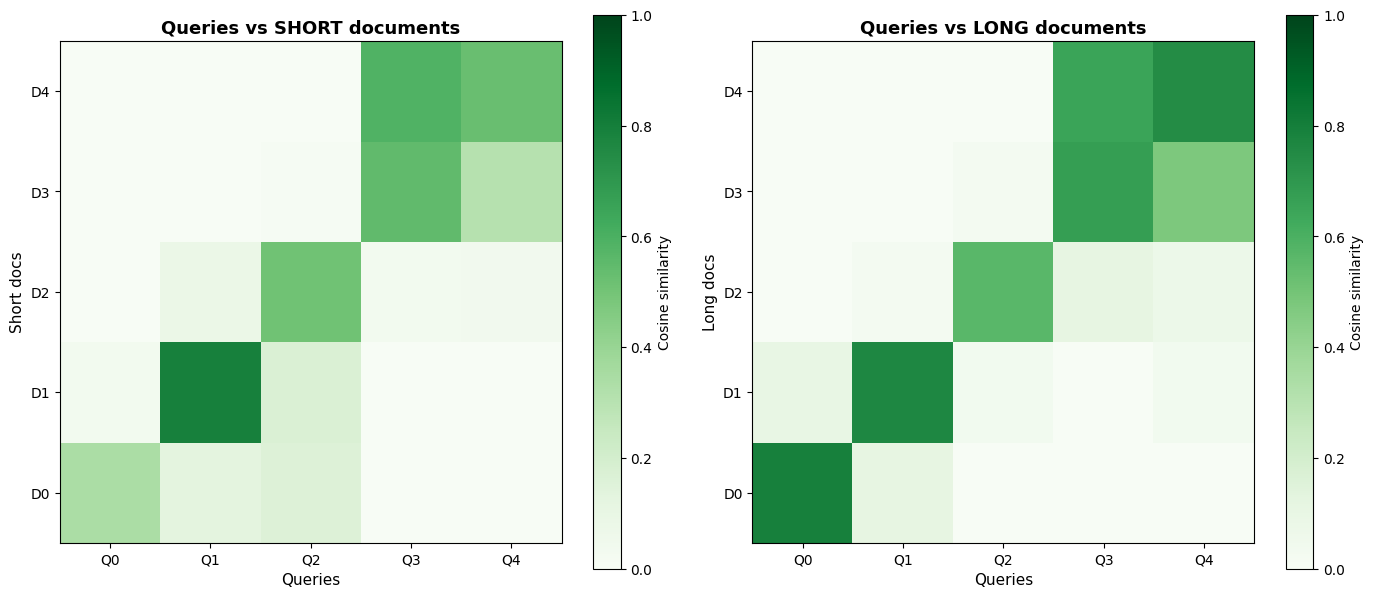

In [21]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0.7, max_tokens=300)

prompt = ChatPromptTemplate.from_template(
    "Write a short paragraph (4-6 sentences) that answers the questions somewhere in its text:\n"
    "{question}\n\n"
    "Use varied vocabulary, Do not start with 'Here is a paragraph:'. Just write directly"
)

chain = prompt | llm | StrOutputParser()

longer_docs = []
for i, q in enumerate(queries):
    longer_doc = chain.invoke({"question": q})
    longer_docs.append(longer_doc)
    print(f"[Q{i}] {q}")
    print(f"→ {longer_doc[:120]}...")
    print()

long_d_embs = model.encode(longer_docs, normalize_embeddings=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plt.sca(axes[0])
plot_similarity_matrix(q_embeddings, d_embeddings,
    xlabel="Queries", ylabel="Short docs",
    title="Queries vs SHORT documents")

plt.sca(axes[1])
plot_similarity_matrix(q_embeddings, long_d_embs,
    xlabel="Queries", ylabel="Long docs",
    title="Queries vs LONG documents")

plt.tight_layout()
plt.show()

## From embeddings to RAG Pipeline

RAG(Retrieval-Augmented Generation): Instead of summarizing whole documents. You store all chunks as embeddings, and at query time you retrieve most relevant chunks and send those to LLM.

Flow

Offline
1. Load documents
2. Split into chunks
3. Embed chunks
4. Store embeddings as vector stores (fiass, chroma, pipecone)

Online
1. Embed the user question
2. Search the vector store for top-k most similar chunks
3. Send the top-k chunks + question to the llm as context
4. Return the LLM answer

In [23]:
import arxiv
import urllib.request
import fitz
from langchain_core.documents import Document

def load_arxiv_papers(query:str, load_max_docs: int = 1) -> list[Document]:
    client = arxiv.Client()
    search = arxiv.Search(query=query, max_results=load_max_docs)
    documents = []

    for result in client.results(search):
        # Download the PDF to a temp file
        pdf_path = f"/tmp/{result.entry_id.split('/')[-1]}.pdf"
        urllib.request.urlretrieve(result.pdf_url, pdf_path)

        # Extract full text with PyMuPDF
        full_text = ""
        with fitz.open(pdf_path) as pdf:
            for page in pdf:
                full_text += page.get_text()

        documents.append(Document(
            page_content=full_text,
            metadata={
                "title":     result.title,
                "authors":   ", ".join(str(a) for a in result.authors),
                "published": str(result.published.date()),
                "summary":   result.summary,
                "entry_id":  result.entry_id,
                "pdf_url":   result.pdf_url,
            }
        ))

    return documents

docs = load_arxiv_papers(query="RAG", load_max_docs=2)
print(docs[0].page_content, "\n")

MultiHop-RAG: Benchmarking Retrieval-Augmented Generation for
Multi-Hop Queries
Yixuan Tang and Yi Yang
Hong Kong University of Science and Technology
{yixuantang,imyiyang}@ust.hk
Abstract
Retrieval-augmented generation (RAG) aug-
ments large language models (LLM) by re-
trieving relevant knowledge, showing promis-
ing potential in mitigating LLM hallucinations
and enhancing response quality, thereby facil-
itating the great adoption of LLMs in prac-
tice. However, we find that existing RAG sys-
tems are inadequate in answering multi-hop
queries, which require retrieving and reasoning
over multiple pieces of supporting evidence.
Furthermore, to our knowledge, no existing
RAG benchmarking dataset focuses on multi-
hop queries. In this paper, we develop a novel
dataset, MultiHop-RAG, which consists of a
knowledge base, a large collection of multi-
hop queries, their ground-truth answers, and
the associated supporting evidence. We detail
the procedure of building the dataset, utiliz-
ing 

In [24]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name="cl100k_base",
    chunk_size=300,
    chunk_overlap=30,
)

splits = text_splitter.split_documents(docs)
print(f"Number Of Chunks: {len(splits)}")
print(f"Avg Chunk Lenght: {sum(len(d.page_content) for d in splits) // len(splits)} chars")
for i in [0, 1, 2, -1]:
    print(f"\n[Chunk {i}] ({len(splits[i].page_content)} chars)")
    print(splits[i].page_content)
    print("─" * 60)

Number Of Chunks: 100
Avg Chunk Lenght: 1060 chars

[Chunk 0] (1263 chars)
MultiHop-RAG: Benchmarking Retrieval-Augmented Generation for
Multi-Hop Queries
Yixuan Tang and Yi Yang
Hong Kong University of Science and Technology
{yixuantang,imyiyang}@ust.hk
Abstract
Retrieval-augmented generation (RAG) aug-
ments large language models (LLM) by re-
trieving relevant knowledge, showing promis-
ing potential in mitigating LLM hallucinations
and enhancing response quality, thereby facil-
itating the great adoption of LLMs in prac-
tice. However, we find that existing RAG sys-
tems are inadequate in answering multi-hop
queries, which require retrieving and reasoning
over multiple pieces of supporting evidence.
Furthermore, to our knowledge, no existing
RAG benchmarking dataset focuses on multi-
hop queries. In this paper, we develop a novel
dataset, MultiHop-RAG, which consists of a
knowledge base, a large collection of multi-
hop queries, their ground-truth answers, and
the associated support

In [27]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

embedder = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True}
)



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


The recent surge in environmental concerns has led to a paradigm shift in global policies, with a pressing emphasis on sustainability and eco-friendliness. This seismic change is reflected in the proliferation of green technologies and renewable energy sources, which are being rapidly integrated into various sectors, including transportation and infrastructure. As a result, the traditional fossil fuel-based economy is slowly giving way to a more environmentally conscious model, where reduced carbon emissions and energy efficiency are paramount. The overarching goal of this shift is to mitigate the detrimental effects of climate change and ensure a livable future for generations to come. By adopting this new vision, nations can work towards a more harmonious coexistence with the planet and its finite resources. Ultimately, this transformation holds the key to a more resilient and sustainable world.


In [ ]:

vector_store = FAISS.from_documents(splits, embedder)
retriever = vector_store.as_retriever(search_kwargs={"k": 3})

llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0.7, max_tokens=300) | StrOutputParser()

def rag_query(question: str) -> str:
    relevant_chunks = retriever.invoke(question)
    context = "\n\n".join(chunk.page_content for chunk in relevant_chunks)
    print(context)
    return llm.invoke(prompt.format(context=context, question=question))

answer = rag_query("What is retrieval augmented generation?")
print(answer)